In [1]:
# Import important libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

In [2]:
# Parameters
tickers = ['INFY.NS', 'TCS.NS', 'RELIANCE.NS']
start = '2024-04-01'
end = '2024-10-01'
initial_capital = 100000

In [3]:
# Data Ingestion
data = yf.download(tickers, start=start, end=end, group_by='ticker')
if len(tickers) >1:
    # Flatten MultiIndex for easy access
    data.columns = ['-'.join(col).strip() for col in data.columns.values]
# Save to csv
data.to_csv('nifty50_stocks.csv')
print('Data saved to nifty50_stocks.csv')
data.head()

/var/folders/12/xvg83yyx5wbctqfvzw4g93f80000gn/T/ipykernel_91596/3119410818.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start=start, end=end, group_by='ticker')
[*********************100%***********************]  3 of 3 completed

Data saved to nifty50_stocks.csv


,TCS.NS-Open,TCS.NS-High,TCS.NS-Low,TCS.NS-Close,TCS.NS-Volume,RELIANCE.NS-Open,RELIANCE.NS-High,RELIANCE.NS-Low,RELIANCE.NS-Close,RELIANCE.NS-Volume,INFY.NS-Open,INFY.NS-High,INFY.NS-Low,INFY.NS-Close,INFY.NS-Volume
Date,,,,,,,,,,,,,,,
2024-04-01,3721.754224,3755.747300,3712.539927,3739.944336,1569676,1481.509590,1482.998569,1471.607901,1473.866211,5013880,1457.744390,1462.476038,1426.964522,1429.497559,6580002
2024-04-02,3714.401769,3733.355815,3698.169165,3708.481689,2142666,1473.096869,1483.023398,1464.162993,1476.025146,8910166,1419.364921,1427.298920,1415.541329,1417.453125,7279400
2024-04-03,3677.162022,3801.293692,3677.162022,3769.114990,3973090,1471.186102,1473.543652,1458.107971,1460.788086,7008292,1413.773087,1429.163021,1409.949495,1415.350342,8736248
2024-04-04,3796.424124,3846.792940,3757.609195,3822.587402,3394637,1468.878094,1468.878094,1439.346671,1452.176758,14490272,1424.813601,1429.688657,1403.258057,1421.133301,11186915
2024-04-05,3798.429229,3821.345846,3781.719196,3799.622803,1636819,1450.141767,1459.993895,1445.302584,1449.372437,7442298,1414.776825,1421.133454,1410.953234,1413.868652,5072482


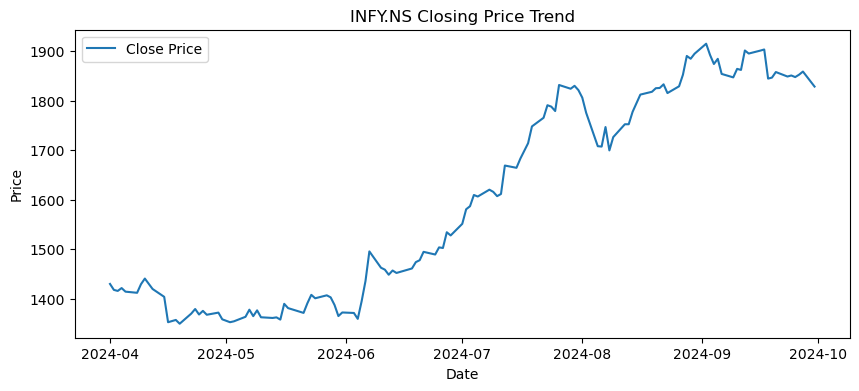

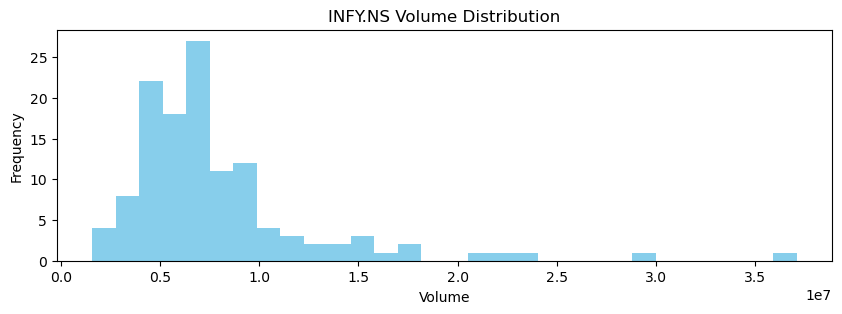

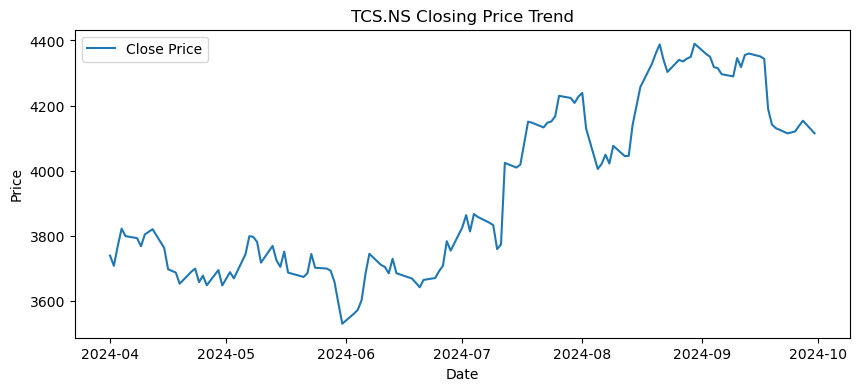

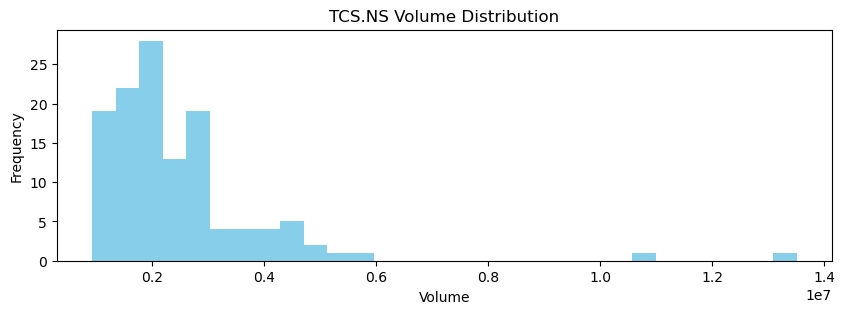

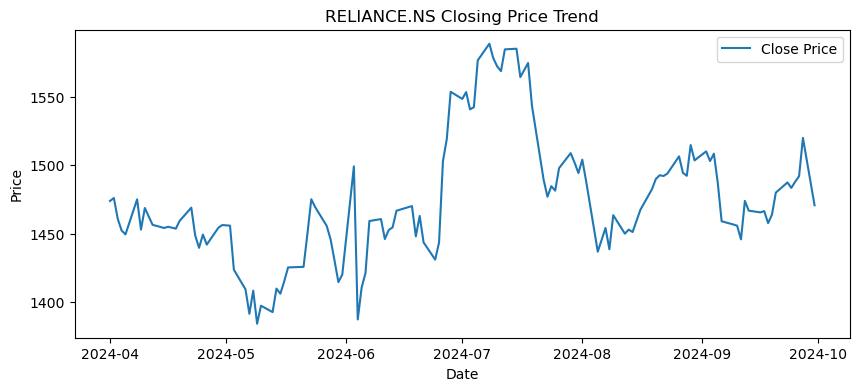

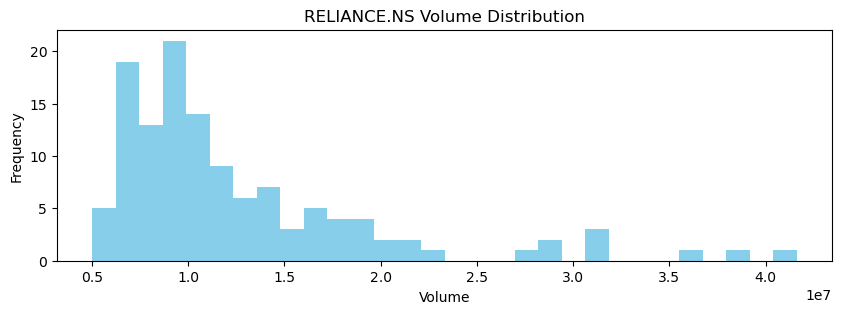

In [4]:
# Basic EDA
for ticker in tickers:
    plt.figure(figsize=(10,4))
    plt.plot(data[f'{ticker}-Close'], label='Close Price')
    plt.title(f'{ticker} Closing Price Trend')
    plt.xlabel('Date')
    plt.ylabel('Price')
    plt.legend()
    plt.show()
    plt.figure(figsize=(10,3))
    plt.hist(data[f'{ticker}-Volume'], bins=30, color='skyblue')
    plt.title(f'{ticker} Volume Distribution')
    plt.xlabel('Volume')
    plt.ylabel('Frequency')
    plt.show()

In [5]:
# Trading Strategy + Backtesting
strategy_results = {}
for ticker in tickers:
    df = data[[f'{ticker}-Close', f'{ticker}-Open', f'{ticker}-High', f'{ticker}-Low', f'{ticker}-Volume']].copy()
    # SMA
    df['SMA20'] = df[f'{ticker}-Close'].rolling(20).mean()
    df['SMA50'] = df[f'{ticker}-Close'].rolling(50).mean()
    # RSI
    delta = df[f'{ticker}-Close'].diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)
    avg_gain = gain.rolling(14).mean()
    avg_loss = loss.rolling(14).mean()
    rs = avg_gain/avg_loss
    df['RSI'] = 100-(100/(1+rs))
    # Signals
    df['Signal'] = 0
    df.loc[(df['RSI'] <30) & (df['SMA20'] >df['SMA50']), 'Signal'] = 1     # Buy
    df.loc[(df['RSI'] >70) | (df['SMA20'] <df['SMA50']), 'Signal'] = -1    # Sell
    # Backtesting
    df['Position'] = df['Signal'].replace(to_replace=0, method='ffill')
    df['Return'] = df[f'{ticker}-Close'].pct_change()
    df['Strategy_Return'] = df['Return']*df['Position']
    df['Cumulative_Strategy'] = (1+ df['Strategy_Return']).cumprod()*initial_capital
    strategy_results[ticker] = df

/var/folders/12/xvg83yyx5wbctqfvzw4g93f80000gn/T/ipykernel_91596/35329357.py:21: FutureWarning: The 'method' keyword in Series.replace is deprecated and will be removed in a future version.
  df['Position'] = df['Signal'].replace(to_replace=0, method='ffill')
/var/folders/12/xvg83yyx5wbctqfvzw4g93f80000gn/T/ipykernel_91596/35329357.py:21: FutureWarning: The 'method' keyword in Series.replace is deprecated and will be removed in a future version.
  df['Position'] = df['Signal'].replace(to_replace=0, method='ffill')
/var/folders/12/xvg83yyx5wbctqfvzw4g93f80000gn/T/ipykernel_91596/35329357.py:21: FutureWarning: The 'method' keyword in Series.replace is deprecated and will be removed in a future version.
  df['Position'] = df['Signal'].replace(to_replace=0, method='ffill')


In [6]:
ticker = "INFY.NS"  # pick any ticker
df = strategy_results[ticker]
df.tail()  # last 10 rows

,INFY.NS-Close,INFY.NS-Open,INFY.NS-High,INFY.NS-Low,INFY.NS-Volume,SMA20,SMA50,RSI,Signal,Position,Return,Strategy_Return,Cumulative_Strategy
Date,,,,,,,,,,,,,
2024-09-24,1851.179321,1840.844098,1863.172156,1824.658734,7277616,1875.991266,1816.560186,44.309253,0,-1,0.001134,-0.001134,76413.050585
2024-09-25,1847.961792,1839.235262,1854.104368,1829.923860,4268341,1873.855963,1820.231147,40.638143,0,-1,-0.001738,0.001738,76545.863882
2024-09-26,1852.788208,1850.399448,1870.046075,1845.719288,8952803,1872.242303,1823.628127,49.544967,0,-1,0.002612,-0.002612,76345.945147
2024-09-27,1859.125854,1883.842674,1925.281168,1855.762071,14908931,1870.440955,1826.527847,53.455184,0,-1,0.003421,-0.003421,76084.796242
2024-09-30,1828.753906,1833.044033,1853.763281,1823.781311,6986955,1866.106976,1828.139563,40.270429,0,-1,-0.016337,0.016337,77327.769378


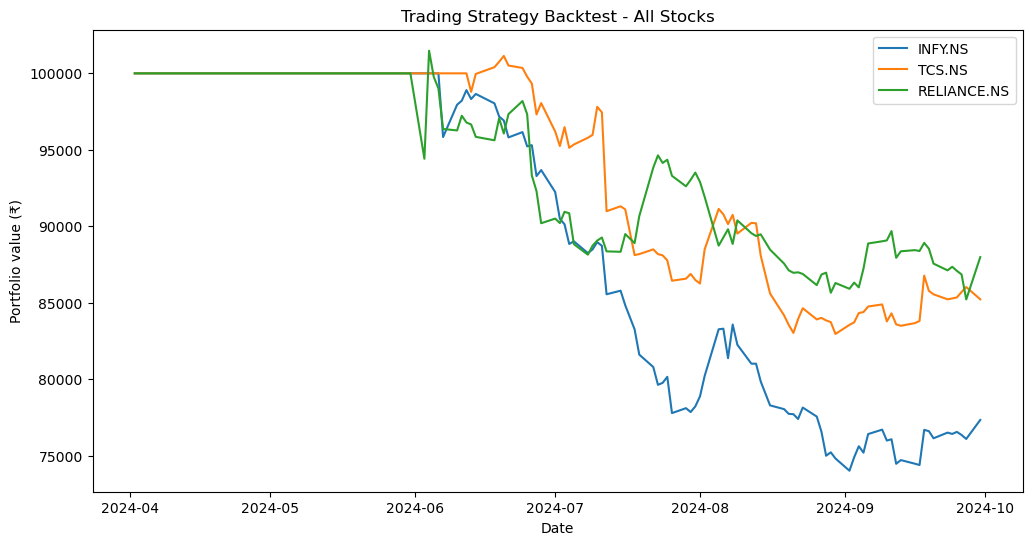


INFY.NS Trade Log (Last 10 Trades):
            INFY.NS-Close  Signal Action
Date                                    
2024-08-01    1806.328247      -1   Sell
2024-08-02    1775.712524      -1   Sell
2024-08-26    1829.290161      -1   Sell
2024-08-27    1852.641846      -1   Sell
2024-08-28    1890.667847      -1   Sell
2024-08-29    1885.061401      -1   Sell
2024-08-30    1895.152832      -1   Sell
2024-09-02    1915.433472      -1   Sell
2024-09-03    1892.764160      -1   Sell
2024-09-04    1874.433594      -1   Sell

TCS.NS Trade Log (Last 10 Trades):
            TCS.NS-Close  Signal Action
Date                                   
2024-08-29   4349.524414      -1   Sell
2024-08-30   4389.964844      -1   Sell
2024-09-02   4358.441406      -1   Sell
2024-09-03   4350.054688      -1   Sell
2024-09-19   4141.630371       1    Buy
2024-09-20   4130.784668       1    Buy
2024-09-23   4114.974609       1    Buy
2024-09-24   4117.673828       1    Buy
2024-09-25   4121.000000       1   

In [7]:
# Plot cumulative P&L
plt.figure(figsize=(12,6))
for ticker in tickers:
    plt.plot(strategy_results[ticker].index, strategy_results[ticker]['Cumulative_Strategy'], label=ticker)
plt.title('Trading Strategy Backtest - All Stocks')
plt.xlabel('Date')
plt.ylabel('Portfolio value (₹)')
plt.legend()
plt.show()
# Trade logs
for ticker in tickers:
    trades = strategy_results[ticker][strategy_results[ticker]['Signal'] != 0][[f'{ticker}-Close', 'Signal']].copy()
    trades['Action'] = trades['Signal'].map({1:'Buy', -1:'Sell'})
    print(f'\n{ticker} Trade Log (Last 10 Trades):')
    print(trades.tail(10))
             

In [8]:
# Machine Learning (Logistic Regression)
features = ['SMA_ratio', 'RSI', 'MACD', 'Vol_Change']
ml_results = {}
for ticker in tickers:
    df = data[[f'{ticker}-Close', f'{ticker}-Volume']].copy()
    # Features
    df['SMA20'] = df[f'{ticker}-Close'].rolling(20).mean()
    df['SMA50'] = df[f'{ticker}-Close'].rolling(50).mean()
    df['SMA_ratio'] = df['SMA20']/df['SMA50']
    delta = df[f'{ticker}-Close'].diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)
    avg_gain = gain.rolling(14).mean()
    avg_loss = loss.rolling(14).mean()
    rs = avg_gain/avg_loss
    df['RSI'] = 100-(100/(1+rs))
    # MACD
    ema12 = df[f'{ticker}-Close'].ewm(span=12, adjust=False).mean()
    ema26 = df[f'{ticker}-Close'].ewm(span=26, adjust=False).mean()
    df['MACD'] = ema12-ema26
    # Volume change
    df['Vol_Change'] = df[f'{ticker}-Volume'].pct_change()
    # Target
    df['Target'] = (df[f'{ticker}-Close'].shift(-1) > df[f'{ticker}-Close']).astype(int)
    df.dropna(inplace=True)
    X = df[['SMA_ratio', 'RSI', 'MACD', 'Vol_Change']]
    y = df['Target']
    # Scale feature
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, shuffle=False)
    # Train Logistic Regression 
    model = LogisticRegression()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    # Evaluation
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)
    ml_results[ticker] = {
        'model': model,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'confusion_matrix': cm
    }
    print(f'\n{ticker} ML Results:')
    print(f'Accuracy:{accuracy: .2f}, Precision: {precision:.2f}, Recall: {recall:.2f}, f1: {f1:.2f}')
    # **Interpret feature coefficients**
    print("Feature Coefficients (Impact on Probability of Upward Movement):")
    for coef, feature in zip(model.coef_[0], features):
        direction = "↑" if coef > 0 else "↓"
        print(f"{feature}: {coef:.4f} {direction}")
    print('Confusion Matrix:\n', cm)


INFY.NS ML Results:
Accuracy: 0.53, Precision: 0.53, Recall: 1.00, f1: 0.70
Feature Coefficients (Impact on Probability of Upward Movement):
SMA_ratio: 0.5593 ↑
RSI: 0.1082 ↑
MACD: -1.1167 ↓
Vol_Change: -0.4648 ↓
Confusion Matrix:
 [[0 7]
 [0 8]]

TCS.NS ML Results:
Accuracy: 0.40, Precision: 0.40, Recall: 1.00, f1: 0.57
Feature Coefficients (Impact on Probability of Upward Movement):
SMA_ratio: 0.4153 ↑
RSI: 0.0106 ↑
MACD: -0.4690 ↓
Vol_Change: -0.0387 ↓
Confusion Matrix:
 [[0 9]
 [0 6]]

RELIANCE.NS ML Results:
Accuracy: 0.53, Precision: 0.54, Recall: 0.88, f1: 0.67
Feature Coefficients (Impact on Probability of Upward Movement):
SMA_ratio: -0.0164 ↓
RSI: -0.0644 ↓
MACD: -0.1416 ↓
Vol_Change: 0.1882 ↑
Confusion Matrix:
 [[1 6]
 [1 7]]


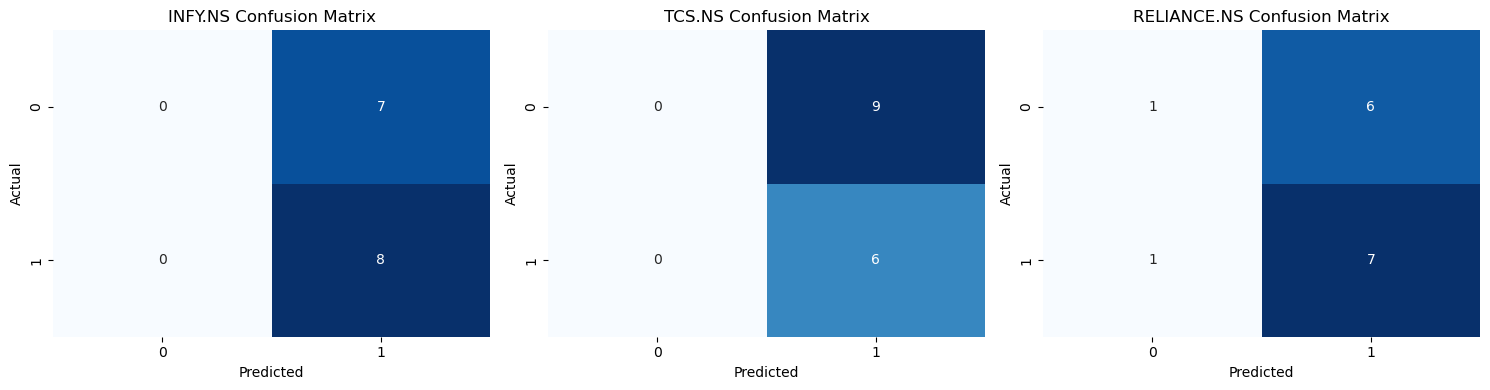

In [9]:
# Combined Confusion Matrix Plot
plt.figure(figsize=(15,4))
for i, ticker in enumerate(tickers, 1):
    cm = ml_results[ticker]['confusion_matrix']
    plt.subplot(1,3,i)
    sns.heatmap(cm, annot=True, fmt= 'd', cmap= 'Blues', cbar=False)
    plt.title(f'{ticker} Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
plt.tight_layout()
plt.show()

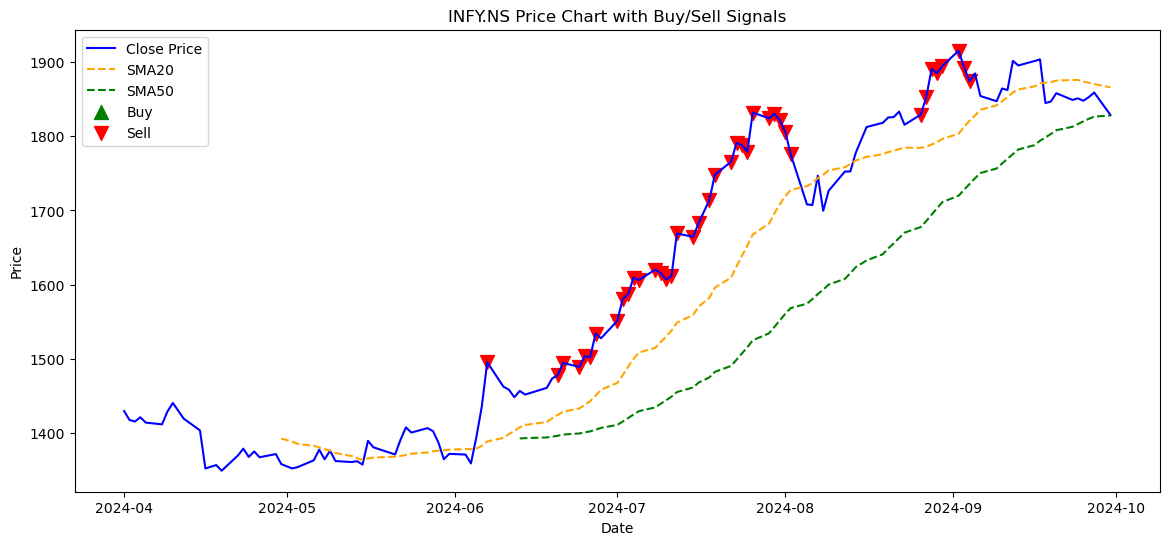

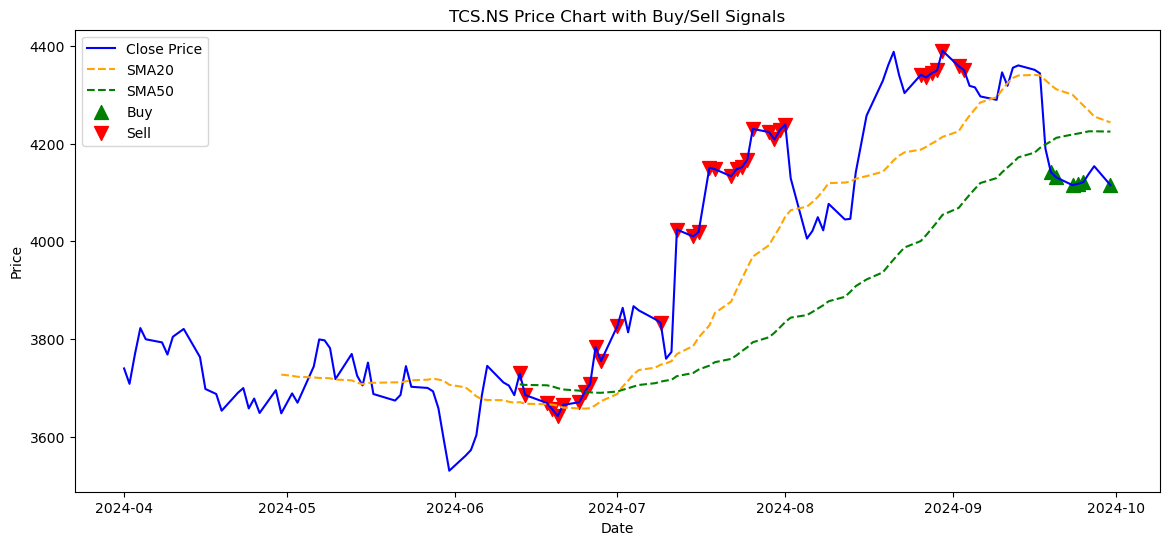

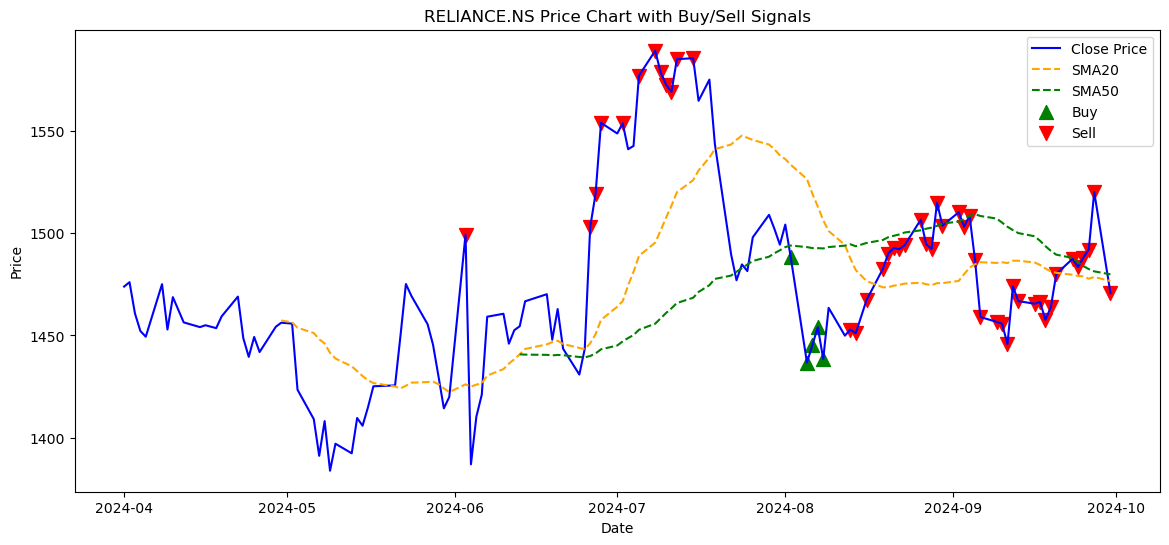

In [10]:
import matplotlib.dates as mdates

for ticker in tickers:
    df = strategy_results[ticker]
    
    # Price chart with SMA
    plt.figure(figsize=(14,6))
    plt.plot(df.index, df[f'{ticker}-Close'], label='Close Price', color='blue')
    plt.plot(df.index, df['SMA20'], label='SMA20', color='orange', linestyle='--')
    plt.plot(df.index, df['SMA50'], label='SMA50', color='green', linestyle='--')
    
    # Mark Buy signals
    buy_signals = df[df['Signal'] == 1]
    plt.scatter(buy_signals.index, buy_signals[f'{ticker}-Close'], marker='^', color='green', s=100, label='Buy')
    
    # Mark Sell signals
    sell_signals = df[df['Signal'] == -1]
    plt.scatter(sell_signals.index, sell_signals[f'{ticker}-Close'], marker='v', color='red', s=100, label='Sell')
    
    plt.title(f'{ticker} Price Chart with Buy/Sell Signals')
    plt.xlabel('Date')
    plt.ylabel('Price')
    plt.legend()
    plt.show()
    

In [12]:
!pip install gspread oauth2client


In [13]:
# (1) Imports and Google Sheets setup
import gspread
from oauth2client.service_account import ServiceAccountCredentials
from datetime import datetime
import time

# (2) Google Sheets API scope
scope = [
    'https://spreadsheets.google.com/feeds',
    'https://www.googleapis.com/auth/drive'
]

# (3) Load service account credentials (your JSON file)
creds = ServiceAccountCredentials.from_json_keyfile_name('tradingbot-credentials.json', scope)
client = gspread.authorize(creds)

# (4) Open or Create Spreadsheet
SHEET_NAME = "algotrading"

try:
    sheet = client.open(SHEET_NAME)
except gspread.SpreadsheetNotFound:
    # If the sheet doesn’t exist, create it
    sheet = client.create(SHEET_NAME)
    print(f"Created new Google Sheet: {SHEET_NAME}")

# (5) Create Worksheets if Missing
# Trade Log Worksheet 
try:
    trade_sheet = sheet.worksheet("Trades")
except:
    trade_sheet = sheet.add_worksheet(title="Trades", rows="1000", cols="10")
    trade_sheet.append_row(['Timestamp', 'Stock', 'Action', 'Price', 'Quantity', 'P&L'])
    print("Created 'Trades' worksheet with headers.")

# (6) Summary Worksheet 
try:
    summary_sheet = sheet.worksheet("Summary")
except:
    summary_sheet = sheet.add_worksheet(title="Summary", rows="100", cols="10")
    summary_sheet.append_row(['Stock', 'Final Capital', 'Total Trades', 'Wins', 'Losses', 'Win/Loss Ratio', 'Timestamp'])
    print("Created 'Summary' worksheet with headers.")

# Logging Section

quantity = 10  # Fixed quantity per trade

# ---- Trade Log ----
rows_to_add = []

for ticker in tickers:
    df = strategy_results[ticker]

    # Select rows with signals
    trades = df[df['Signal'] != 0].copy()
    if trades.empty:
        continue

    trades['Action'] = trades['Signal'].map({1: 'Buy', -1: 'Sell'})
    trades['Timestamp'] = trades.index.strftime('%Y-%m-%d')
    trades['Stock'] = ticker
    trades['Price'] = trades[f'{ticker}-Close']
    trades['Quantity'] = quantity
    trades['P&L'] = trades['Signal'] * trades['Price'].pct_change().fillna(0) * quantity * trades['Price']

    for _, row in trades.iterrows():
        rows_to_add.append([
            str(row['Timestamp']),
            str(row['Stock']),
            str(row['Action']),
            float(round(row['Price'], 2)),
            int(quantity),
            float(round(row['P&L'], 2))
        ])

# Batch upload to avoid rate-limit errors
if rows_to_add:
    trade_sheet.append_rows(rows_to_add)
    print(f"Logged {len(rows_to_add)} trade entries to Google Sheets.")
else:
    print("No trades to log.")

# ---- Summary Log ----
summary_rows = []

for ticker in tickers:
    df = strategy_results[ticker]

    final_value = df['Cumulative_Strategy'].iloc[-1]
    trades = df[df['Signal'] != 0]
    returns = df['Strategy_Return'].dropna()

    wins = int((returns > 0).sum())
    losses = int((returns < 0).sum())
    win_loss_ratio = float(round(wins / (losses + 1e-5), 2))

    summary_rows.append([
        str(ticker),
        float(round(final_value, 2)),
        int(len(trades)),
        int(wins),
        int(losses),
        win_loss_ratio,
        datetime.now().strftime('%Y-%m-%d %H:%M:%S')
    ])

if summary_rows:
    summary_sheet.append_rows(summary_rows)
    print(f"Logged {len(summary_rows)} summary records to Google Sheets.")
else:
    print("No summary data to log.")


Logged 130 trade entries to Google Sheets.
Logged 3 summary records to Google Sheets.
